In [78]:
import os
os.environ["PATH"] = "/opt/homebrew/bin:/opt/homebrew/sbin:" + os.environ.get("PATH", "")

In [79]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline



In [80]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')
    


In [81]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b
e.label='e'
d = e + c
d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label='L'


In [82]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [83]:
d._op

'+'

In [84]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

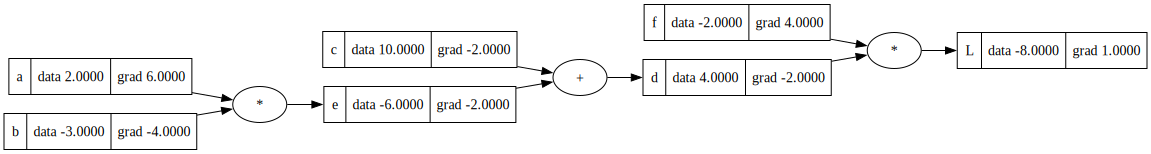

In [105]:
draw_dot(L)

In [104]:
# WANT dL / da

# dL / de = -2
# de / da = -3
# dL / de * de / da = 6

# de / db = 2
# de / db * dL / de = -4

a.grad = 6
b.grad = -4



In [100]:
e.grad = -2
c.grad = -2

In [ ]:
dd / dc = 

d = c + e = f(x)

(c + e + h - c - e) / h

h / h = 1

dL/dc = dL/dd * dd/dc = -2 * 1 = -2




In [98]:
L.grad = 1.0
f.grad=4.0
d.grad = -2.0


In [103]:
def lol():
    h = 0.0001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label='e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0 + h, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label='e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data

    print ((L2 - L1) / h)

lol()




-4.000000000008441
